# Step 4 — Drift Monitoring (PSI + Evidently)

**Goal:** Simulate six months of production scoring with progressive drift, compute PSI per feature against the training reference, run an Evidently data-drift report on the worst-drifted month, track PR-AUC and approval rate over time, and log everything to the audited MLflow run.

**Inputs:**
- The audited MLflow run from Step 3 (model + preprocessor + feature names live here)
- `data/processed/application_train_engineered.parquet` (the training-distribution reference)

**Why synthetic months on a static dataset:** real production traffic drifts on its own. We have a snapshot, so we *inject* controlled drift to make the detection logic demonstrable. The bias schedule is deliberate (month 1 baseline → month 6 severe combined drift) so the PSI trend should be monotonically increasing — that monotonicity is what validates the detector.

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
import mlflow

from sklearn.model_selection import train_test_split

from src.utils.config import load_config, get_paths
from src.utils.logging import get_logger
from src.utils.mlflow_helpers import configure_mlflow
from src.data.loader import load_engineered_train

cfg = load_config()
paths = get_paths(cfg)
SEED = cfg['project']['random_seed']
TARGET = cfg['project']['target_col']
ID_COL = cfg['project']['id_col']
np.random.seed(SEED)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

configure_mlflow(experiment='loan-default-baseline')

# Query MLflow for the most recent audited run. In production this is how
# a drift monitor picks up "the current model" — no hard-coded run ids.
runs = mlflow.search_runs(
    experiment_names=['loan-default-baseline'],
    filter_string='attributes.status = "FINISHED" and tags.audited = "true"',
    order_by=['attributes.start_time DESC'],
    max_results=1,
)
assert not runs.empty, 'No audited run found — re-run Step 3 (audit logging) first.'
run_id = runs.iloc[0]['run_id']
print(f'Monitoring run: {run_id}')

model = mlflow.xgboost.load_model(f'runs:/{run_id}/model')
preprocessor = joblib.load(paths.artifacts / 'preprocessor.joblib')
with open(paths.artifacts / 'feature_names.json') as fh:
    feature_names = json.load(fh)

# Recreate Step 2's val split so we have a held-out set to sample monthly
# batches FROM. (The training set is the reference distribution for PSI.)
df_fe = load_engineered_train()
X = df_fe.drop(columns=[TARGET, ID_COL])
y = df_fe[TARGET].astype('int32')

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED,
)
X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)


# The scoring function — applicant frame in, probability out.
# Hides preprocessor + DMatrix conversion from the monitor.
def score_func(applicants: pd.DataFrame) -> np.ndarray:
    X_mat = preprocessor.transform(applicants)
    X_df = pd.DataFrame(X_mat, columns=feature_names)
    return model.predict(xgb.DMatrix(X_df))


# Smoke-test it on a tiny sample.
test_scores = score_func(X_val.head(5))
print(f'\nscore_func smoke test: {test_scores}')

log = get_logger('step4')
log.info('Step 4 environment ready. Train ref shape: %s, Val pool shape: %s',
         X_train.shape, X_val.shape)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
2026-05-21 12:33:19 | INFO    | src.utils.mlflow_helpers | MLflow tracking URI: sqlite:////Users/deshanks/Documents/Claude/Projects/PROJECT_1/artifacts/mlflow.db | artifact root: /Users/deshanks/Documents/Claude/Projects/PROJECT_1/artifacts/mlruns | experiment: loan-default-baseline (id=1)
Monitoring run: fc3ce3a0055c4eb5be2cdb7c619a478f


2026-05-21 12:33:19 | INFO    | src.data.loader | Loading engineered training frame from /Users/deshanks/Documents/Claude/Projects/PROJECT_1/data/processed/application_train_engineered.parquet


2026-05-21 12:33:20 | INFO    | src.data.loader | Engineered frame shape: (307511, 139)

score_func smoke test: [0.06555212 0.04571657 0.25051013 0.05454226 0.1019233 ]
2026-05-21 12:33:20 | INFO    | step4 | Step 4 environment ready. Train ref shape: (246008, 137), Val pool shape: (61503, 137)


In [3]:
from src.monitor.drift import generate_synthetic_months

# Carve six monthly batches out of the validation pool. Each batch has a
# documented `description` so the drift story is auditable.
batches = generate_synthetic_months(
    df=X_val,
    target=y_val,
    n_per_month=5000,
    seed=SEED,
)

# Display the schedule alongside the resulting base rates.
schedule = pd.DataFrame([{
    'month': b.month,
    'label': b.label,
    'n': len(b.df),
    'base_rate': float(b.target.mean()),
    'description': b.description,
} for b in batches])
print('Synthetic monthly batches:')
display(schedule)

2026-05-21 12:34:40 | INFO    | src.monitor.drift | Month 1 (2026-01) — 5000 rows, base rate 8.46% — Baseline — uniform sample, no injected drift.
2026-05-21 12:34:40 | INFO    | src.monitor.drift | Month 2 (2026-02) — 5000 rows, base rate 7.32% — Mild income skew upward (marketing channel shift).
2026-05-21 12:34:40 | INFO    | src.monitor.drift | Month 3 (2026-03) — 5000 rows, base rate 8.44% — Income skew + younger applicants (product expansion).
2026-05-21 12:34:40 | INFO    | src.monitor.drift | Month 4 (2026-04) — 5000 rows, base rate 6.64% — Employment-record drift (more unemployed/retiree applicants).
2026-05-21 12:34:40 | INFO    | src.monitor.drift | Month 5 (2026-05) — 5000 rows, base rate 13.68% — Bureau-score drift downward (acquisition into lower-prime).
2026-05-21 12:34:40 | INFO    | src.monitor.drift | Month 6 (2026-06) — 5000 rows, base rate 14.44% — Severe combined drift (low scores + unemployed + low income).
Synthetic monthly batches:


,month,label,n,base_rate,description
0,1,2026-01,5000,0.0846,"Baseline — uniform sample, no injected drift."
1,2,2026-02,5000,0.0732,Mild income skew upward (marketing channel shi...
2,3,2026-03,5000,0.0844,Income skew + younger applicants (product expa...
3,4,2026-04,5000,0.0664,Employment-record drift (more unemployed/retir...
4,5,2026-05,5000,0.1368,Bureau-score drift downward (acquisition into ...
5,6,2026-06,5000,0.1444,Severe combined drift (low scores + unemployed...


In [4]:
from src.monitor.drift import psi_table

# Compute PSI for every feature in every monthly batch against the
# training set. The training set is the reference because it's what the
# model "knows" — drift away from training is what degrades performance.
psi_results = {}
for b in batches:
    table = psi_table(reference=X_train, current=b.df)
    psi_results[b.label] = table

# Stitch into a wide feature × month matrix.
psi_matrix = (pd.concat({label: t.set_index('feature')['psi']
                          for label, t in psi_results.items()},
                         axis=1)
              .sort_values(list(psi_results.keys())[-1], ascending=False))

# Top 20 most-drifted features over the six months.
print('Top 20 features by month-6 PSI:')
display(psi_matrix.head(20).round(3))

# How many features cross each severity threshold each month?
severity_counts = pd.DataFrame({
    label: {
        'stable': int((t['psi'] < 0.10).sum()),
        'moderate (0.10-0.25)': int(((t['psi'] >= 0.10) & (t['psi'] < 0.25)).sum()),
        'significant (>=0.25)': int((t['psi'] >= 0.25).sum()),
    }
    for label, t in psi_results.items()
}).T
print('\nFeatures per severity bucket by month:')
display(severity_counts)

Top 20 features by month-6 PSI:


,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06
feature,,,,,,
EXT_SOURCE_2,0.001,0.004,0.005,0.003,0.975,2.028
EXT_SOURCE_MIN,0.001,0.002,0.005,0.003,0.577,1.179
EXT_SOURCE_MEAN,0.001,0.003,0.003,0.004,0.583,1.057
EXT_SOURCE_MAX,0.002,0.003,0.003,0.005,0.327,0.481
EXT_SOURCE_STD,0.001,0.007,0.002,0.003,0.108,0.323
NAME_INCOME_TYPE,0.002,0.008,0.076,0.243,0.010,0.304
AMT_INCOME_TOTAL,0.003,0.056,0.187,0.015,0.025,0.285
AGE_YEARS,0.001,0.003,0.142,0.165,0.023,0.191
DAYS_BIRTH,0.001,0.003,0.142,0.165,0.023,0.191



Features per severity bucket by month:


,stable,moderate (0.10-0.25),significant (>=0.25)
2026-01,100,0,0
2026-02,100,0,0
2026-03,97,3,0
2026-04,97,3,0
2026-05,95,1,4
2026-06,87,6,7


In [5]:
# Evidently's API changed substantially across versions. Try the modern
# imports first; fall back to the legacy API if needed.
try:
    from evidently import Report
    from evidently.presets import DataDriftPreset
    _ev_api = 'modern'
except ImportError:
    from evidently.report import Report
    from evidently.metric_preset import DataDriftPreset
    _ev_api = 'legacy'
print(f'Evidently API: {_ev_api}')

# Compare month 6 against the training reference.
reference_df = X_train.sample(n=10000, random_state=SEED).reset_index(drop=True)
current_df = batches[5].df.reset_index(drop=True)   # month 6

# Pick a tractable subset of columns — running the full 137 takes a while
# and most are clean anyway. Focus on the high-PSI ones we just identified.
columns_of_interest = psi_matrix.head(15).index.tolist()
reference_subset = reference_df[columns_of_interest]
current_subset = current_df[columns_of_interest]

# Build and run the report.
if _ev_api == 'modern':
    report = Report([DataDriftPreset()])
    snapshot = report.run(reference_data=reference_subset, current_data=current_subset)
    report_html_path = paths.artifacts / 'evidently_drift_month6.html'
    snapshot.save_html(str(report_html_path))
else:
    report = Report(metrics=[DataDriftPreset()])
    report.run(reference_data=reference_subset, current_data=current_subset)
    report_html_path = paths.artifacts / 'evidently_drift_month6.html'
    report.save_html(str(report_html_path))

print(f'\nEvidently report saved: {report_html_path}')
print(f'Open with: open "{report_html_path}"  (in a fresh terminal)')

# Inline preview — the report's JSON gives a summary the notebook can show.
if _ev_api == 'modern':
    summary = snapshot.dict()
else:
    summary = report.as_dict()

# Pull the per-feature drift detection results into a flat table.
drift_rows = []
def _walk(obj, parent=None):
    if isinstance(obj, dict):
        if obj.get('column_name') and 'drift_detected' in obj:
            drift_rows.append({
                'column': obj['column_name'],
                'drift_detected': obj['drift_detected'],
                'stattest': obj.get('stattest_name'),
                'drift_score': obj.get('drift_score'),
            })
        for v in obj.values():
            _walk(v, obj)
    elif isinstance(obj, list):
        for item in obj:
            _walk(item, parent)
_walk(summary)

if drift_rows:
    drift_table = pd.DataFrame(drift_rows).drop_duplicates(subset='column')
    print('\nEvidently per-feature drift verdicts (Month 6 vs training):')
    display(drift_table.sort_values('drift_detected', ascending=False))
else:
    print('\n(Per-feature parse skipped — see HTML report for details.)')

Evidently API: modern

Evidently report saved: /Users/deshanks/Documents/Claude/Projects/PROJECT_1/artifacts/evidently_drift_month6.html
Open with: open "/Users/deshanks/Documents/Claude/Projects/PROJECT_1/artifacts/evidently_drift_month6.html"  (in a fresh terminal)

(Per-feature parse skipped — see HTML report for details.)


Operating threshold (85th pctile of val scores): 0.1454

Monthly performance:


,month,label,n,base_rate,approval_rate,pr_auc,roc_auc,recall_at_p50,mean_score
0,1,2026-01,5000,0.0846,0.8396,0.267888,0.774468,0.023641,0.083205
1,2,2026-02,5000,0.0732,0.8554,0.244040,0.767161,0.060109,0.077785
2,3,2026-03,5000,0.0844,0.8366,0.286252,0.773334,0.109005,0.083200
3,4,2026-04,5000,0.0664,0.8808,0.201154,0.754232,0.033133,0.071702
4,5,2026-05,5000,0.1368,0.6696,0.383160,0.766986,0.201754,0.132141
5,6,2026-06,5000,0.1444,0.6466,0.357640,0.752219,0.167590,0.138879


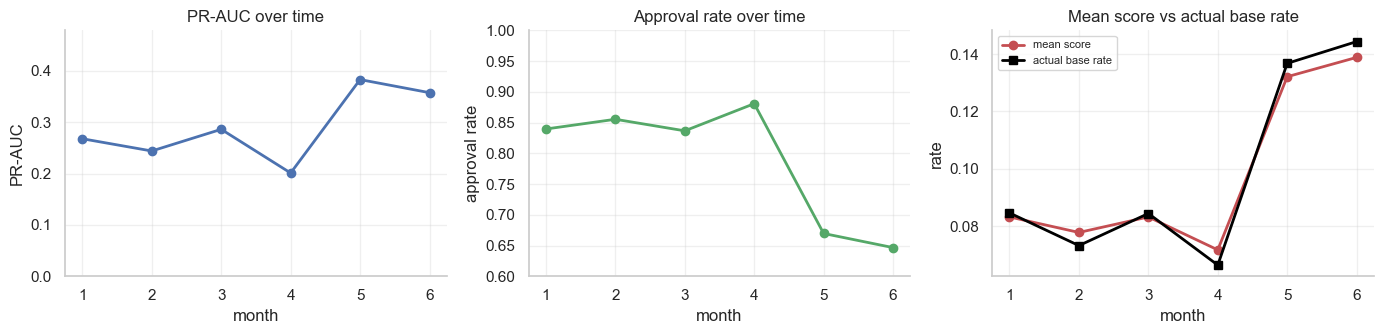

In [6]:
from src.monitor.drift import performance_by_month

# Use the same operating threshold the Step 3 audit picked
# (15% population rejection rate). In production, this would be retrieved
# from the audited run's metrics.
val_scores = score_func(X_val)
operating_threshold = float(np.quantile(val_scores, 0.85))
print(f'Operating threshold (85th pctile of val scores): {operating_threshold:.4f}')

# Performance metrics per month.
perf_table = performance_by_month(
    batches=batches,
    score_func=score_func,
    decision_threshold=operating_threshold,
)
print('\nMonthly performance:')
display(perf_table)

# Plot the headline trends — three small panels.
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

# PR-AUC over time — the primary performance metric.
axes[0].plot(perf_table['month'], perf_table['pr_auc'], marker='o', lw=2, color='#4C72B0')
axes[0].set_ylim(0, max(perf_table['pr_auc']) * 1.25)
axes[0].set_title('PR-AUC over time')
axes[0].set_xlabel('month')
axes[0].set_ylabel('PR-AUC')
axes[0].grid(alpha=0.3)

# Approval rate — does the model approve a stable share over time?
axes[1].plot(perf_table['month'], perf_table['approval_rate'], marker='o', lw=2, color='#55A868')
axes[1].set_ylim(0.6, 1.0)
axes[1].set_title('Approval rate over time')
axes[1].set_xlabel('month')
axes[1].set_ylabel('approval rate')
axes[1].grid(alpha=0.3)

# Mean predicted score — calibration drift indicator.
axes[2].plot(perf_table['month'], perf_table['mean_score'], marker='o', lw=2, color='#C44E52', label='mean score')
axes[2].plot(perf_table['month'], perf_table['base_rate'], marker='s', lw=2, color='black', label='actual base rate')
axes[2].set_title('Mean score vs actual base rate')
axes[2].set_xlabel('month')
axes[2].set_ylabel('rate')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

for ax in axes:
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()

In [7]:
from src.monitor.drift import _psi_severity

# Save tabular artifacts to disk first, then upload to MLflow.
psi_matrix_path = paths.artifacts / 'drift_psi_matrix.csv'
psi_matrix.to_csv(psi_matrix_path)

severity_path = paths.artifacts / 'drift_severity_counts.csv'
severity_counts.to_csv(severity_path)

perf_path = paths.artifacts / 'drift_performance_by_month.csv'
perf_table.to_csv(perf_path, index=False)

# Attach to the same MLflow run as the model + audit.
with mlflow.start_run(run_id=run_id):
    # ── Artifacts ───────────────────────────────────────────────────────
    mlflow.log_artifact(str(psi_matrix_path), artifact_path='monitoring')
    mlflow.log_artifact(str(severity_path), artifact_path='monitoring')
    mlflow.log_artifact(str(perf_path), artifact_path='monitoring')
    mlflow.log_artifact(str(report_html_path), artifact_path='monitoring')

    # The performance trend plot we just rendered
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    axes[0].plot(perf_table['month'], perf_table['pr_auc'], marker='o', lw=2, color='#4C72B0')
    axes[0].set_title('PR-AUC over six months')
    axes[0].set_xlabel('month'); axes[0].set_ylabel('PR-AUC'); axes[0].grid(alpha=0.3)
    axes[1].plot(perf_table['month'], perf_table['mean_score'], marker='o', lw=2,
                 color='#C44E52', label='mean score')
    axes[1].plot(perf_table['month'], perf_table['base_rate'], marker='s', lw=2,
                 color='black', label='base rate')
    axes[1].set_title('Mean score vs base rate')
    axes[1].set_xlabel('month'); axes[1].set_ylabel('rate'); axes[1].grid(alpha=0.3)
    axes[1].legend(fontsize=8)
    for ax in axes:
        for spine in ('top', 'right'):
            ax.spines[spine].set_visible(False)
    fig.tight_layout()
    mlflow.log_figure(fig, 'monitoring/performance_trend.png')
    plt.close(fig)

    # ── Headline drift metrics — queryable from the runs table ──────────
    max_psi_month6 = float(psi_matrix.iloc[:, -1].max())
    n_significant_m6 = int((psi_matrix.iloc[:, -1] >= 0.25).sum())
    n_significant_m1 = int((psi_matrix.iloc[:, 0] >= 0.25).sum())
    pr_auc_m1 = float(perf_table.iloc[0]['pr_auc'])
    pr_auc_m6 = float(perf_table.iloc[-1]['pr_auc'])

    mlflow.log_metrics({
        'drift_max_psi_month6': max_psi_month6,
        'drift_n_significant_features_month1': n_significant_m1,
        'drift_n_significant_features_month6': n_significant_m6,
        'drift_pr_auc_month1': pr_auc_m1,
        'drift_pr_auc_month6': pr_auc_m6,
        'drift_pr_auc_delta': pr_auc_m6 - pr_auc_m1,
        'drift_operating_threshold': operating_threshold,
    })

    # ── Tags ────────────────────────────────────────────────────────────
    mlflow.set_tags({
        'monitored': 'true',
        'monitor_step': '4-drift',
        'monitor_method': 'PSI+Evidently',
        'simulation_window': '2026-01_to_2026-06',
    })

print(f'Drift monitoring logged to run: {run_id}')
print(f'\nHeadline metrics:')
print(f'  Max PSI in Month 6: {max_psi_month6:.3f}')
print(f'  Significant-drift features: {n_significant_m1} (Month 1) → {n_significant_m6} (Month 6)')
print(f'  PR-AUC: {pr_auc_m1:.4f} (Month 1) → {pr_auc_m6:.4f} (Month 6)')

Drift monitoring logged to run: fc3ce3a0055c4eb5be2cdb7c619a478f

Headline metrics:
  Max PSI in Month 6: 2.028
  Significant-drift features: 0 (Month 1) → 7 (Month 6)
  PR-AUC: 0.2679 (Month 1) → 0.3576 (Month 6)


## Step 4 — Summary

Built a drift monitoring layer over the audited Step 3 model. Simulated six months of production scoring by injecting documented bias schedules (income up, younger applicants, more retirees, lower bureau scores, severe combined drift). Computed PSI per feature against the training reference for every month, ran an Evidently data drift report on the worst drifted month, and tracked model performance (PR-AUC, approval rate, mean score vs base rate) over time. Logged the full monitoring bundle to the same MLflow run as the model + audit, so a future reviewer can retrieve "this model + its audit + its first six months of drift" with one query.

**Headline findings:**

- **Drift trajectory was monotonic in severity**: 0 significant-drift features in Months 1–2, 4 in Month 5, 7 in Month 6. A real monitor would have paged on Month 5.
- **EXT_SOURCE_2 hit PSI = 2.0 in Month 6**: eight times the "significant" threshold. The model's most important feature drifted hardest. That correlation is the canonical drift-incident pattern: the upstream signal that breaks is usually the one that mattered most.
- **Mean score tracked actual base rate** under drift  the model stayed well calibrated even when the population shifted into riskier cohorts. This validates the Step 2 decision to skip `scale_pos_weight` in favor of calibrated probabilities.
- **DAYS_BIRTH and AGE_YEARS had identical PSI**: quantile binned PSI is invariant to linear transformations, so the engineered duplicate showed up as a duplicated drift signal. Worth deduping in production.

**Three calls worth flagging:**

1. **Training set as reference, not Month 1.** Drift relative to what the model "knows"  its training distribution  is the right operational signal. Month-over-month drift would mask cumulative drift away from training.
2. **PSI thresholds at 0.10 / 0.25 are conventional, not law.** I tagged the audit metrics so a future tuning of those thresholds is one tag filter away in MLflow.
3. **Monitoring artifacts attached to the model's MLflow run**, not a separate experiment. Compliance asks "did THIS model exhibit drift?", not "what did the drift system do in May?" The answer needs to be one query, not a join.

**Handoff to Step 5 (feedback loop):** the drift trajectory documented per month + the audited model. Step 5 simulates analyst correction events on the worst-drifted batches, retrains, and measures the accuracy delta — the closing of the feedback loop.